# `py4conjoint.choice` — デモ（選択型コンジョイント分析）

このノートブックは `py4conjoint.choice` の基本的な **関数・属性・メソッド** を
実データ（ヨーグルト購買データ）で動作確認するためのものです。

| セクション | 内容 |
|:---:|------|
| 0 | セットアップ |
| 1 | 選択型コンジョイント分析（CBC）とは |
| 2 | `pcc.design_choice_sets()` — 選択セットの設計 |
| 3 | `pcc.check_design()` — 設計の診断 |
| 4 | `pcc.suggest_n_respondents()` — 必要回答者数の目安 |
| 5 | `pcc.forms_to_data()` — アンケートファイルの読み込み |
| 6 | ヨーグルト購買データ |
| 7 | `pcc.encode()` — ダミーコーディング（0/1） |
| 8 | `pcc.fit()` — 条件付きロジット |
| 9 | `result.warnings()` — 落とし穴チェック |
| 10 | `result.importance()` — 重要度 |
| 11 | `result.wtp()` — WTP（限界支払意思額） |
| 12 | `result.market_share()` — 市場シェア予測 |
| 13 | 可視化（`plot_importance / plot_partworth / plot_wtp`） |
| 14 | rating 版（評点型）との違い |

## 0. セットアップ

In [1]:
import numpy as np
import pandas as pd
import py4conjoint.choice as pcc

print(f"py4conjoint version: {pcc.__version__}")

py4conjoint version: 0.4.0a1


## 1. 選択型コンジョイント分析（CBC）とは

評点型（rating 版）では、回答者に製品案（プロファイル）を **1つずつ** 見せて
「10点満点で何点？」と評価してもらいました。

選択型（CBC：Choice-Based Conjoint）では、回答者に **複数の製品案を同時に**
見せて「この中ならどれを買う？」と **1つ選んでもらいます**。

* 同時に見せる製品案のまとまりを **選択セット**（＝アンケートの1設問）と呼びます。
* スーパーの棚から1つ選ぶのと同じ行動なので、**実際の購買行動に近い**
  データが取れるのが最大の長所です。
* 分析には **条件付きロジット（conditional logit）** という統計モデルを使います。
  「各製品が選ばれる確率」を、属性の魅力度（効用）から説明するモデルです。

ワークフローは rating 版と対称的です：

```
設計        → アンケート → 読み込み           → 符号化     → 推定      → 解釈
design_choice_sets  Forms   forms_to_data   encode      fit       summary / importance / wtp / ...
```

## 2. `pcc.design_choice_sets()` — 選択セットの設計

CBC 用の選択セット（設問）を生成する関数です。
全属性水準の組み合わせ（完全交差）から、各設問にランダムに代替案を
割り当てます。**同じ設問の中に同じ製品案が重複して入ることはありません。**

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `attributes` | dict | — | `{"属性名": [水準1, 水準2, ...]}` の辞書 |
| `n_sets` | int | — | 設問数（選択セット数） |
| `n_alts` | int | — | 1設問あたりの代替案の数 |
| `n_versions` | int | `1` | アンケートのバージョン数 |
| `seed` | int | `None` | 乱数シード（再現性のため） |

**返り値**: long 形式 DataFrame（列：`version`, `choice_set_id`, `alt_id` + 属性列）。
1 行 = 1つの設問の中の1つの代替案。

In [2]:
design = pcc.design_choice_sets(
    {"price": [100, 150, 200], "brand": ["A社", "B社", "C社"]},
    n_sets=8,    # 設問数
    n_alts=3,    # 1設問あたり3つの代替案から選ぶ
    seed=42,
)
design.head(6)  # 設問1・設問2に提示する代替案

,version,choice_set_id,alt_id,price,brand
0,1,1,1,150,C社
1,1,1,2,100,A社
2,1,1,3,200,A社
3,1,2,1,100,A社
4,1,2,2,200,C社
5,1,2,3,200,A社


## 3. `pcc.check_design()` — 設計の診断

アンケートを実施する **前** に、作った設計の品質をチェックする関数です。
rating 版の `check_design()` と同様、`summary()`（和文サマリー）と
`warnings()`（DataFrame）を持つ `ChoiceDesignCheckResult` を返します。

**診断項目**

| 項目 | 内容 | 良い状態 |
|------|------|---------|
| 水準バランス | 各水準が均等に出現しているか（CV） | CV が小さい（◎） |
| 独立性（χ²） | 2属性の組み合わせが偏っていないか | χ²/自由度 が小さい（◎） |
| セット内オーバーラップ | 設問内の全代替案が同じ水準になる設問の割合 | 率が小さい（◎） |

オーバーラップが多い属性は、その設問では「どれを選んでも同じ」なので
比較情報を生まず、推定精度が下がります。

In [3]:
check = pcc.check_design(design)
print(check.summary())

選択セット設計チェック

【水準バランス】（CV が小さいほど均等）
 属性  水準数  最大出現  最小出現   CV  評価
price       3         8         8  0.0     ◎
brand       3        12         4  0.5     △

【独立性（χ²統計量）】（自由度に対して小さいほど独立）
属性1  属性2    χ²  自由度  χ²/自由度  評価
price  brand  0.75       4     0.1875     ○

【セット内オーバーラップ】（全代替案が同じ水準になる設問の割合。小さいほど良い）
 属性  オーバーラップ率  評価
price               0.0     ◎
brand               0.0     ◎

【警告】
  [大] 属性 'brand' の水準出現頻度が偏っています（CV=0.500）。
      → 設問数（n_sets）またはバージョン数（n_versions）を増やすか、seed を変えて再生成してください。


In [4]:
# 警告だけを DataFrame で取り出すこともできる（rating 版と同じ使い勝手）
check.warnings()

,severity,category,message,recommendation
0,大,balance_brand,属性 'brand' の水準出現頻度が偏っています（CV=0.500）。,設問数（n_sets）またはバージョン数（n_versions）を増やすか、seed を変え...


## 4. `pcc.suggest_n_respondents()` — 必要回答者数の目安

CBC で何人にアンケートすべきかを **Johnson-Orme の経験則** で計算します。

$$n \;\geq\; \frac{500 \times c}{t \times a}$$

* $c$ … 最大水準数（いちばん水準が多い属性の水準数）
* $t$ … 設問数（1人が答える選択セット数）
* $a$ … 1設問あたりの代替案数

「各水準が少なくとも500回は提示される」ことを目安とするルールです。

In [5]:
pcc.suggest_n_respondents(
    {"price": [100, 150, 200], "brand": ["A社", "B社", "C社"]},
    n_sets=8,
    n_alts=3,
)

Johnson-Orme の経験則: n ≥ 500 × c / (t × a)
  最大水準数 c = 3, 設問数 t = 8, 代替案数 a = 3
  → 必要回答者数の目安: 63 人以上
  （サブグループ別に分析する場合はグループごとにこの人数が必要です）


,水準数,必要回答者数（目安）
属性,,
price,3,63
brand,3,63


## 5. `pcc.forms_to_data()` — アンケートファイルの読み込み

Microsoft Forms（`.xlsx`）/ Google Forms（`.csv`）の回答ファイルを、
条件付きロジット推定用の **long 形式 DataFrame** に変換する関数です。

**前提とするアンケート形式**

* **1設問 = 1選択セット**。設問の回答選択肢が代替案
  （例：「製品A」「製品B」「製品C」）。
* 回答値から代替案を特定するために、設計（`design`）と
  `choice_labels`（回答文字列に含まれるラベル）を渡します。

> **実ファイルの見え方**：実際の Forms では設問の列名が選択肢を含む長文
> （例：`"次の3つのうち、最も購入したい…\n・製品A：価格 6万円　｜　OS Apple (iOS) …"`、
> 改行・全角空白・`\xa0` を含む）になり、回答値は短いラベル
> （`"製品A"` / `"製品B"` / `"製品C"`）になります。本関数は **列名ではなく
> 回答値** で設問列を見分けるので、列名の表記ゆれ（`【設問１】` などの接頭辞の
> 有無を含む）があっても正しく動きます。性別・利用OS などの属性質問が
> 混ざっていても自動で除外されます。

> **Google Forms の CSV について**：Google Forms の回答 CSV は **BOMなし
> UTF-8** のことが多く、Excel でそのまま開くと日本語が文字化けします。
> しかしファイル自体は正常で、`py4conjoint` は `forms="google"` で正しく
> 読み込めます（BOMなし・BOM付きの両方に対応）。Excel で中身を確認したい
> 場合は、Google スプレッドシートに取り込んでから `.xlsx` で書き出すか、
> Excel の「データ」→「テキスト/CSV から」で文字コードに UTF-8 を指定して
> インポートしてください。

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `responses_file` | str | — | アンケートファイルのパス（.xlsx / .csv） |
| `design` | DataFrame | — | `design_choice_sets()` の出力（または `choice_set_id`/`alt_id` を持つ設計表） |
| `choice_labels` | list | — | 代替案を識別するラベル（`alt_id` の順） |
| `forms` | str | `"microsoft"` | `"microsoft"` または `"google"` |
| `version` | int | `1` | design のどのバージョンを使うか |
| `respondent_cols` | dict | `None` | 回答者属性として残したい列の対応辞書 |
| `out_csv` | str | `None` | 変換後 DataFrame を CSV で保存するパス |

**返り値**: long 形式 DataFrame
（列：`respondent_id`, `choice_set_id`（回答者×設問の通し番号）, `alt`, `choice`(0/1) + 属性列。rating 版と同じく回答者を先頭にした列順）。
そのまま `encode()` → `fit()` に渡せます。

> **補足**: 評点型・選択型のどちらも同じ関数名 `forms_to_data()` を使い、名前空間で使い分けます（評点型は `pcr.forms_to_data()`、選択型は `pcc.forms_to_data()`）。

In [6]:
# --- デモ用に Microsoft Forms 形式の回答ファイルを作る（実際の授業では
# --- Forms からダウンロードした .xlsx をそのまま使えばよい）
rng = np.random.default_rng(0)
mock = {
    "ID": range(1, 11),
    "Start time": ["2026-06-01 10:00"] * 10,
    "Completion time": ["2026-06-01 10:05"] * 10,
}
for q in range(1, 9):
    mock[f"Q{q}. どの製品を選びますか？"] = [
        f"製品{rng.choice(['A', 'B', 'C'])}" for _ in range(10)
    ]
pd.DataFrame(mock).to_excel("responses_choice_demo.xlsx", index=False)

# --- 回答ファイル → long 形式
df_forms = pcc.forms_to_data(
    "responses_choice_demo.xlsx",
    design=design,                    # セクション2で作った設計
    choice_labels=["A", "B", "C"],    # 「製品A」→ alt 1, 「製品B」→ alt 2, ...
)
df_forms.head(6)

,respondent_id,choice_set_id,alt,choice,price,brand
0,1,1,1,0,150,C社
1,1,1,2,0,100,A社
2,1,1,3,1,200,A社
3,1,2,1,0,100,A社
4,1,2,2,1,200,C社
5,1,2,3,0,200,A社


## 6. ヨーグルト購買データ

ここからは、マーケティング研究で広く使われる **ヨーグルト購買データ**
（R のパッケージ `logitr` に収録。Jain et al. 1994）で推定を体験します。

* 100 世帯のヨーグルト購買記録：**2412 回の購買機会（選択セット）× 4 ブランド = 9648 行**
* 1 行 = 1つの購買機会で棚に並んでいた1ブランド

| 列 | 内容 |
|----|------|
| `id` | 世帯ID（回答者IDに相当） |
| `obsID` | 購買機会のID（選択セットID）。`logitr` 由来の慣習名。py4conjoint では `choice_set_id` に統一するため、読み込み後にこの列を `choice_set_id` にリネームして使う |
| `alt` | 代替案番号（1〜4） |
| `choice` | その購買機会で選ばれたら 1、それ以外 0 |
| `price` | 価格（セント/オンス） |
| `feat` | 新聞広告に掲載されていたか（0/1） |
| `brand` | ブランド（dannon / hiland / weight / yoplait） |

In [7]:
df = pd.read_csv("../tests/data/yogurt.csv")
# yogurt.csv の選択セット列は logitr 慣習名 "obsID"。
# py4conjoint の公開 API の列名 "choice_set_id" にそろえる。
df = df.rename(columns={"obsID": "choice_set_id"})
print(f"行数: {len(df)}, 選択セット数: {df['choice_set_id'].nunique()}, 世帯数: {df['id'].nunique()}")
df.head(8)  # 最初の2つの購買機会

行数: 9648, 選択セット数: 2412, 世帯数: 100


,id,choice_set_id,alt,choice,price,feat,brand
0,1,1,1,0,8.1,0,dannon
1,1,1,2,0,6.1,0,hiland
2,1,1,3,1,7.9,0,weight
3,1,1,4,0,10.8,0,yoplait
4,1,2,1,1,9.8,0,dannon
5,1,2,2,0,6.4,0,hiland
6,1,2,3,0,7.5,0,weight
7,1,2,4,0,10.8,0,yoplait


### `choice_set_id` と `respondent_id` の関係（階層構造）

選択型データは **2階層** になっています。

- **`respondent_id`**（ここでは世帯 `id`）… 「誰が」答えたか。1人 = 1回答者。
- **`choice_set_id`** … 「どの質問（購買機会）」か。1つの選択セット = 1回の選択。

**1人の回答者（`respondent_id`）が複数の選択セット（`choice_set_id`）に回答します。**
同じ `id` の回答者が複数の `choice_set_id` を持ち、各 `choice_set_id` の中に
複数の代替案（`alt`）が並び、そのうち1つだけ `choice=1` になります。

`fit()` の `respondent_id_col` にこの回答者IDを渡すと、同じ回答者の繰り返し回答が
独立でないことを考慮した **クラスタロバスト標準誤差** が使われます。

In [8]:
# 回答者 id=1 が回答した選択セット（choice_set_id）を確認する
one = df[df["id"] == 1][["id", "choice_set_id", "alt", "choice", "brand"]]
print(f"回答者 id=1 が回答した選択セット数: {one['choice_set_id'].nunique()}")
print(f"全体: {df['id'].nunique()} 人の回答者が、計 {df['choice_set_id'].nunique()} 個の選択セットに回答")
one.head(8)   # 1人の回答者が複数の choice_set_id を持つ（各セットに4代替案・choice=1は1つ）

回答者 id=1 が回答した選択セット数: 8
全体: 100 人の回答者が、計 2412 個の選択セットに回答


,id,choice_set_id,alt,choice,brand
0,1,1,1,0,dannon
1,1,1,2,0,hiland
2,1,1,3,1,weight
3,1,1,4,0,yoplait
4,1,2,1,1,dannon
5,1,2,2,0,hiland
6,1,2,3,0,weight
7,1,2,4,0,yoplait


## 7. `pcc.encode()` — ダミーコーディング（0/1）

カテゴリ属性を **0/1 のダミーコーディング** に変換する関数です。

> **rating 版との違いに注意**：rating 版の `encode()` は ±1 の
> **効果コーディング**でしたが、choice 版は 0/1 の **ダミーコーディング** です。
> 条件付きロジットでは「基準水準と比べてどれだけ選ばれやすいか」という
> 解釈が直感的なため、ダミーコーディングが標準です。

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `df` | DataFrame | — | long 形式のデータ |
| `reference_levels` | dict | — | `{"属性名": 基準水準}`。基準水準の効用が 0 に固定される |
| `suffix_map` | dict | `None` | 生成する列名のサフィックスを手動指定 |
| `drop_original` | bool | `False` | 元の属性列を削除するか |
| `inplace` | bool | `False` | 入力 df を直接書き換えるか |

**返り値の列名ルール**：K 水準の属性 → 基準水準 **以外** の水準ごとに
`{属性名}_{水準名}` が K-1 列追加（例：`brand_hiland`）。
基準水準の行はすべて 0。

価格（`price`）や広告掲載（`feat`）のような **数値変数はダミー化せず**、
そのまま説明変数に入れます。

In [9]:
df_coded = pcc.encode(df, reference_levels={"brand": "dannon"})
df_coded.head(8)  # brand_hiland / brand_weight / brand_yoplait が追加される

,id,choice_set_id,alt,choice,price,feat,brand,brand_hiland,brand_weight,brand_yoplait
0,1,1,1,0,8.1,0,dannon,0,0,0
1,1,1,2,0,6.1,0,hiland,1,0,0
2,1,1,3,1,7.9,0,weight,0,1,0
3,1,1,4,0,10.8,0,yoplait,0,0,1
4,1,2,1,1,9.8,0,dannon,0,0,0
5,1,2,2,0,6.4,0,hiland,1,0,0
6,1,2,3,0,7.5,0,weight,0,1,0
7,1,2,4,0,10.8,0,yoplait,0,0,1


## 8. `pcc.fit()` — 条件付きロジットの推定

符号化済み DataFrame に **条件付きロジット（conditional logit）** を適用し、
`ChoiceConjointResult` を返す関数です。

条件付きロジットは「選択セット内の各代替案 $j$ が選ばれる確率」を

$$P(j) = \frac{\exp(V_j)}{\sum_k \exp(V_k)}, \qquad V_j = \beta_1 x_{j1} + \beta_2 x_{j2} + \cdots$$

とモデル化します。$V_j$ は代替案 $j$ の **効用** で、係数 $\beta$ は
最尤法（scipy.optimize）で推定されます。

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `df` | DataFrame | — | 符号化済み long 形式データ |
| `choice` | str | `"choice"` | 選択フラグ（0/1）の列名 |
| `choice_set_id_col` | str | `"choice_set_id"` | 選択セットID の列名 |
| `encoded_columns` | list | `None` | 説明変数。省略時は `encode()` のメタ情報 + `price_col` から自動検出 |
| `reference_levels` | dict | `None` | `encode()` に渡したのと同じ辞書（省略時は自動取得） |
| `price_col` | str | `"price"` | 価格列の名前（WTP 計算で使う） |
| `respondent_id_col` | str | `"respondent_id"` | 回答者ID列の名前 |
| `cluster_se` | bool | `True` | 回答者IDでグループ化したクラスタロバスト標準誤差を使うか |

`feat` のような **ダミー化していない数値変数** は自動検出に含まれないため、
`encoded_columns` で明示的に指定します。

In [10]:
result = pcc.fit(
    df_coded,
    choice="choice",
    choice_set_id_col="choice_set_id",
    encoded_columns=["price", "feat",
                     "brand_hiland", "brand_weight", "brand_yoplait"],
    respondent_id_col="id",     # 世帯IDでクラスタロバスト標準誤差
)

result  # summary() が表示される

============================================================
選択型コンジョイント分析の結果（和文サマリー）
============================================================
観測数（行数）              : 9648
選択セット数                : 2412
説明変数の数                : 5
対数尤度                    : -2656.8879
擬似決定係数 R²（McFadden） : 0.2054
標準誤差                    : クラスタロバスト（id）

【推定された係数（部分効用 part-worth）】
  変数                            係数        p値  有意性
  ------------------------- ---------- ----------  ------
  price                        -0.3666     0.0000  ***
  feat                          0.4914     0.0113  *
  brand_hiland                 -3.7156     0.0000  ***
  brand_weight                 -0.6412     0.1517  
  brand_yoplait                 0.7346     0.0081  **

  有意水準: *** p<0.001  ** p<0.01  * p<0.05  . p<0.1
============================================================

係数の読み方（ダミーコーディング）：

* `price` の係数が **負** → 価格が高いほど選ばれにくい（妥当）。
* `brand_hiland` の係数が **負** → hiland は基準の dannon より選ばれにくい。
* `brand_yoplait` の係数が **正** → yoplait は dannon より選ばれやすい。
* 擬似決定係数 R²（McFadden）は OLS の R² とは別物で、0.2〜0.4 で
  「十分良い適合」とされます。

## 9. `result.warnings()` — 落とし穴チェック

推定で自動検出された **診断警告** の一覧を返します（rating 版と同じ使い勝手）。

**自動検出される警告の種類（choice 版）**

| カテゴリ | 重大度 | 検出タイミング | 内容 |
|----------|:------:|:-----------:|------|
| `separation` | 大 | `fit()` 直後 | 完全分離の疑い（収束失敗・係数が異常に大きい） |
| `few_choice_sets` | 大/中 | `fit()` 直後 | 選択セット数／説明変数数の比率が低い（< 5 → 大、< 10 → 中） |
| `unbalanced_choices` | 中 | `fit()` 直後 | 特定の位置の代替案ばかり選ばれている（≥ 80%） |
| `few_respondents` | 大/中 | `fit()` 直後 | 回答者数が少ない（1人 → 大、2〜4人 → 中） |
| `independence_assumed` | 中 | `fit()` 直後 | 回答者ID列が無く、観測の独立性を仮定 |
| `price_sign_positive` | 中 | `fit()` 直後 | 価格係数が正かつ有意（価格↑で選ばれやすい？） |
| `price_insignificant` | 中 | `wtp()` 呼出時 | 価格の p 値 ≥ 0.10 |
| `wtp_extrapolation` | 中 | `wtp()` 呼出時 | \|WTP\| > 価格レンジ × 2 |

**主要引数**：`severity`（重大度でフィルタ）、`category`（カテゴリでフィルタ）、
`as_dataframe`（`False` で `Diagnostic` のリスト）。

In [11]:
# wtp() を先に呼んで価格関連の警告も生成させる
result.wtp()

result.warnings()

,severity,category,message,recommendation


## 10. `result.importance()` — 重要度

各属性の **効用範囲（部分効用の最大 − 最小）の比率** として重要度を計算します。

* ダミーコーディングした属性 → 効用 = {0（基準水準）} ∪ {各係数} の範囲
* 数値変数（price, feat） → |係数| × データ上のレンジ

重要度は「調査で使った水準レンジ」に依存する **相対指標** です。
レンジの違う調査間で比較してはいけません。

In [12]:
print("【as_percent=True（デフォルト）— 合計 100%】")
imp_pct = result.importance(as_percent=True)
print(imp_pct)
print(f"  合計: {imp_pct['重要度'].sum():.1f}%")

【as_percent=True（デフォルト）— 合計 100%】
           効用範囲        重要度
属性                        
price  6.965105  58.497310
feat   0.491433   4.127366
brand  4.450171  37.375324
  合計: 100.0%


## 11. `result.wtp()` — WTP（限界支払意思額）

条件付きロジットでは、価格係数 $\beta_{price}$ が「お金1単位の効用」を
表すため、各属性の係数を価格係数で割ることで **金額に換算** できます：

$$\text{MWTP} = -\frac{\beta_{attr}}{\beta_{price}}$$

ダミー変数なら「基準水準からその水準に変えるために追加で支払ってもよい金額」、
数値変数なら「その変数1単位あたりの支払意思額」です。
単位は price 列と同じ（このデータではセント/オンス）。

In [13]:
wtp_df = result.wtp()
print(wtp_df)

# attrs に保存されたメタ情報も確認できる
print()
print(f"価格係数の p 値: {wtp_df.attrs['p_price']:.4f}")
print(f"価格レンジ: {wtp_df.attrs['price_low']} 〜 {wtp_df.attrs['price_high']}")

                     係数    限界支払意思額
属性（符号化列名）                         
feat           0.491433   1.340574
brand_hiland  -3.715600 -10.135727
brand_weight  -0.641184  -1.749077
brand_yoplait  0.734571   2.003825

価格係数の p 値: 0.0000
価格レンジ: 0.3 〜 19.3


### 価格をダミーコーディングした場合の区間別 WTP

上のヨーグルトの例では価格を **数値（線形）変数** のまま `encoded_columns` に
入れたので、WTP は属性ごとに1つの値でした。

価格を `encode()` で **ダミーコーディング** すると、各価格水準の効用が独立に
推定され、価格が **3水準以上** のときは **隣接する価格水準の区間ごと** に
別々の価格感応度で WTP を計算できます（`method="segment"`、デフォルト）。

- 価格は **数値列** を `price_col` で指定し、ダミー列（`price_8` など）は
  `encoded_columns` に入れます（rating / choice 共通のルール）。
- 戻り値には `価格区間` 列が付きます。`method="linear"` なら従来の線形近似
  1本（単一値）になります。
- 特定の区間だけ見たいときは `price_segment="8〜10"`（または `(8, 10)`）。

■ 区間別 WTP（デフォルト method='segment'）
           価格区間        係数   限界支払意思額
属性（符号化列名）                          
brand_B     6〜8  0.579164  4.103764
brand_B    8〜10  0.579164  0.936759

■ 特定の価格区間だけ取り出す（price_segment）
           価格区間        係数   限界支払意思額
属性（符号化列名）                          
brand_B    8〜10  0.579164  0.936759


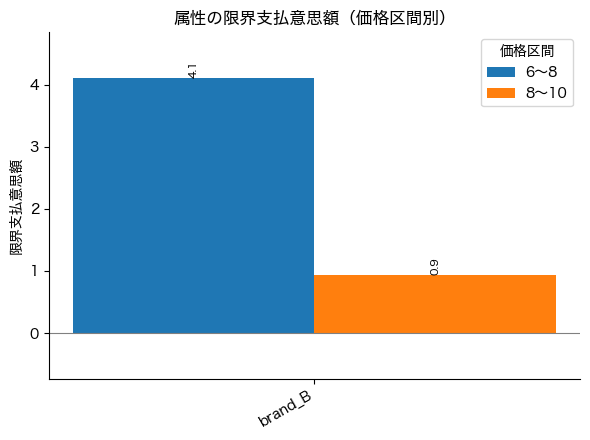

In [14]:
# --- 価格をダミーコーディングして区間別 WTP を出す -----------------------
# price_col には「数値列名」を渡し、価格ダミー（price_8, price_10）は
# encode() が作って encoded_columns に入れる（rating と共通のルール）。
rng_seg = np.random.default_rng(0)
util_p = {6: 0.0, 8: -0.3, 10: -1.6}        # 8→10 で価格感応度が高い（非線形）
rows_seg = []
for t in range(8000):
    pr = rng_seg.choice([6, 8, 10], 3)
    br = rng_seg.choice(["A", "B"], 3)
    v = np.array([util_p[p] + (0.6 if b == "B" else 0.0) for p, b in zip(pr, br)])
    prob = np.exp(v - v.max())
    prob = prob / prob.sum()
    ch = (rng_seg.random() < prob.cumsum()).argmax()
    for j in range(3):
        rows_seg.append({"choice_set_id": t, "choice": int(j == ch),
                         "price": int(pr[j]), "brand": br[j]})
df_seg = pd.DataFrame(rows_seg)

coded_seg = pcc.encode(df_seg, reference_levels={"price": 6, "brand": "A"})
res_seg = pcc.fit(
    coded_seg, choice="choice", choice_set_id_col="choice_set_id",
    encoded_columns=["price_8", "price_10", "brand_B"],
    price_col="price",          # ← ダミーでも「元の数値列名」を渡す
)

print("■ 区間別 WTP（デフォルト method='segment'）")
print(res_seg.wtp())
print("\n■ 特定の価格区間だけ取り出す（price_segment）")
print(res_seg.wtp(price_segment="8〜10"))

# 区間別 WTP をグループ化棒グラフで可視化
# （横軸=属性、価格区間ごとに色分け。棒の高さは上の表と必ず一致する）
ax = res_seg.plot_wtp()

## 12. `result.market_share()` — 市場シェア予測

複数の製品（プロファイル）の効用を計算し、市場シェアを予測します。

| method | 内容 |
|--------|------|
| `"logit"`（デフォルト） | ロジット式 $\text{share}_i = \exp(u_i) / \sum_j \exp(u_j)$。**条件付きロジットの選択確率そのもの** |
| `"max"` | 最大効用ルール。最大効用の製品にシェア1（消費者が完全合理的という仮定） |

`products` の各行は `encoded_columns` と同じ列（ダミー列は 0/1、数値列は実際の値）を持たせます。

In [15]:
products = pd.DataFrame(
    {                    # 製品X    製品Y   製品Z
        "price":         [  8.0,    10.0,    6.0],
        "feat":          [    0,       1,      0],
        "brand_hiland":  [    0,       0,      1],   # 製品Z = hiland
        "brand_weight":  [    0,       0,      0],
        "brand_yoplait": [    1,       0,      0],   # 製品X = yoplait
    },                                               # 製品Y = dannon（全ダミー0）
    index=["製品X（yoplait・8.0）",
           "製品Y（dannon・10.0・広告あり）",
           "製品Z（hiland・6.0）"],
)

print('【method="logit"（デフォルト）】')
share_logit = result.market_share(products, method="logit")
print(share_logit)
print(f"  合計: {share_logit.sum():.6f}")

print()
print('【method="max"（最大効用ルール）】')
share_max = result.market_share(products, method="max")
print(share_max)

【method="logit"（デフォルト）】
製品X（yoplait・8.0）         0.713773
製品Y（dannon・10.0・広告あり）    0.268878
製品Z（hiland・6.0）          0.017349
Name: market_share, dtype: float64
  合計: 1.000000

【method="max"（最大効用ルール）】
製品X（yoplait・8.0）         1.0
製品Y（dannon・10.0・広告あり）    0.0
製品Z（hiland・6.0）          0.0
Name: market_share, dtype: float64


## 13. 可視化

3 つの可視化関数はいずれも **`result.plot_*()`**（メソッド）と
**`pcc.plot_*()`**（モジュールレベル関数）の 2 通りで呼び出せます。
すべて `matplotlib.axes.Axes` を返すので `ax.set_title()` 等で後から調整できます。

| 関数/メソッド | 主な引数 | 説明 |
|---|---|---|
| `plot_importance()` | `sort`, `show_values`, `color` | 重要度の水平棒グラフ |
| `plot_partworth()` | `show_zero_line` | 各水準の部分効用グラフ（基準水準＝0 も明示） |
| `plot_wtp()` | `sort`, `show_values`, `price_unit` | WTP の水平棒グラフ |

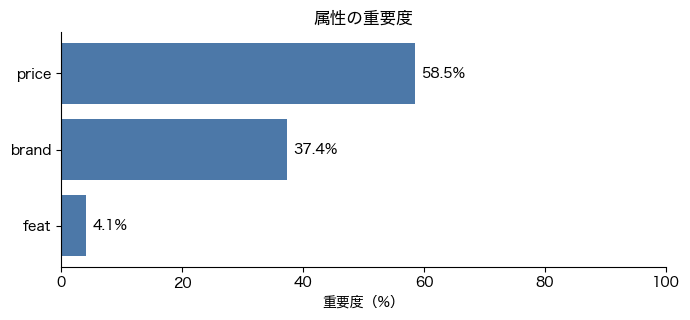

In [16]:
# plot_importance — 重要度
ax = result.plot_importance()
pass

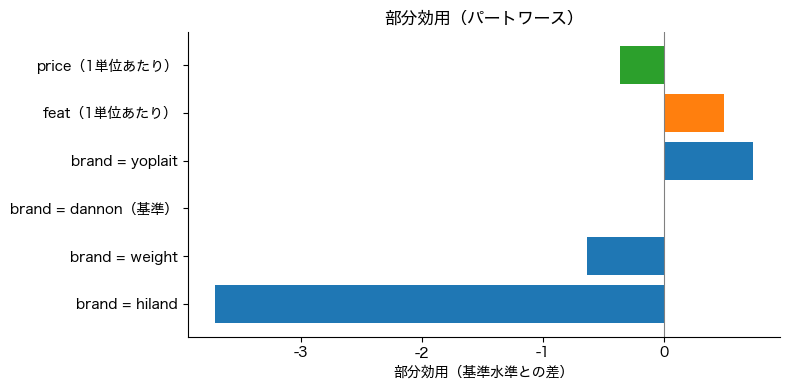

In [17]:
# plot_partworth — 部分効用
# ダミーコーディングでは基準水準（dannon）の効用は 0。
# 「dannon（基準）」の棒が 0 の位置にあることを確認しよう。
# 各係数は「基準水準との差」を表す。
ax = result.plot_partworth()
pass

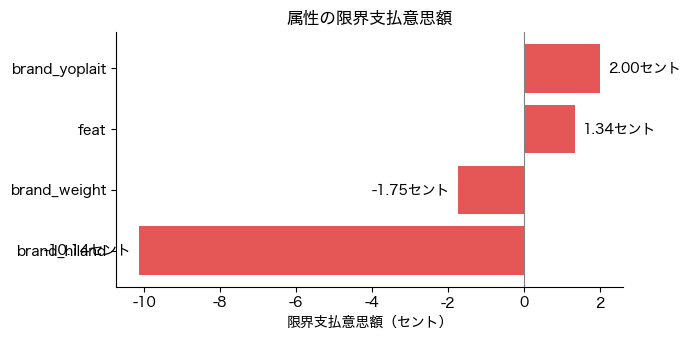

In [18]:
# plot_wtp — 限界支払意思額（単位：セント/オンス）
ax = result.plot_wtp(price_unit="セント")
pass

## 14. rating 版（評点型）との違い

| 観点 | rating 版（評点型） | choice 版（選択型・CBC） |
|------|--------------------|--------------------------|
| 回答者のタスク | 製品案を1つずつ **採点**（例：10点満点） | 複数の製品案から **1つを選ぶ** |
| 統計モデル | OLS 回帰（評点を効用とみなす） | 条件付きロジット（選択確率をモデル化、最尤法） |
| 符号化 | **効果コーディング（−1/+1）**：係数は「全水準の平均との差」 | **ダミーコーディング（0/1）**：係数は「基準水準との差」 |
| 適合度 | R²（評点のばらつきの説明割合） | 擬似 R²（McFadden。別物なので直接比較不可） |
| `market_share()` の根拠 | 評点→効用→ロジット式は **追加の仮定**（評点が効用の代理という仮定の上に、さらにロジット選択を仮定） | ロジット式が **推定モデルそのもの**（選択確率を直接推定しているので理論的に一貫） |

ひとことで言うと：rating 版は「気持ち（評点）」を、choice 版は「行動（選択）」を
データにします。市場シェアの予測が目的なら、選択行動を直接モデル化している
choice 版の方が理論的な裏付けが強い、というのが使い分けの目安です。